### Deep Learning Final Project

### Deep Learning Regression for Stellar Age Estimation of Red Giant Stars

### Problem and Dataset

**Problem**: Estimating the age of red giant stars from their observable properties using a deep learning regression model. Stellar ages are notoriously difficult to measure directly — they are typically inferred through asteroseismology (analysis of stellar oscillations) combined with spectroscopy. Training a neural network to predict stellar ages from readily observable parameters could enable rapid age estimation for large stellar surveys.

**Dataset**: The **APO-K2 catalogue** (Schonhut-Stasik et al. 2024, AJ, 167, 208), accessed via the VizieR astronomical database (`J/AJ/167/208/table3`). This catalogue combines:
- **APOGEE spectroscopic parameters**: effective temperature (`Teff`), surface gravity (`logg`), metallicity (`[Fe/H]`), alpha-element abundance (`[a/M]`), oxygen abundance (`[O/Fe]`).
- **Asteroseismic parameters** from K2: frequency of maximum oscillation power (`numax`), large frequency spacing (`deltanu`).
- **Derived stellar properties**: mass (`Mstar`), radius (`Rstar`).
- **Target variable**: Stellar age (mode of the posterior distribution, `Age-mode`), in Gyr.

The raw dataset contains 1912 red giant stars. After quality filtering (removing non-physical values, high-uncertainty ages, and missing data), 936 stars remain for modelling.


In [2]:
import os
os.makedirs('plots', exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Astronomy data access
from astroquery.vizier import Vizier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

/Users/nakulpandit/Desktop/Modules/deep learning/final Project/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
# Loading the APO-K2 stellar age catalog from VizieR
catalog_id = "J/AJ/167/208/table3"

vizier = Vizier(
    columns=[
        "EPIC", "GaiaEDR3", "Teff", "e_Teff", "logg", "e_logg",
        "[Fe/H]", "e_[Fe/H]", "[a/M]", "e_[a/M]", "[O/Fe]", "e_[O/Fe]",
        "Mstar", "e_Mstar", "Rstar", "e_Rstar", "logg-seis", "e_logg-seis",
        "numax", "e_numax", "deltanu", "e_deltanu",
        "Age", "e_Age", "E_Age", "Age-mode"
    ],
    row_limit=-1
)

tables = vizier.get_catalogs(catalog_id)
table = tables[0]
df = table.to_pandas()

print("Shape:", df.shape)
print(df.head())
print(df.columns.tolist())

Shape: (1912, 26)
        EPIC             GaiaEDR3  Teff  e_Teff  logg  e_logg  [Fe/H]  \
0  211837778   656372815030872192  4759       9  2.38    0.02  -0.306   
1  210915682    58475709154017280  4757       9  2.44    0.03  -0.335   
2  210352614    37590412768055040  4755       9  2.36    0.03  -0.556   
3  214710068  4073182748305313536  4643      10  2.18    0.03  -0.774   
4  212351370  3607531430651890048  4999      11  2.47    0.03  -0.461   

   e_[Fe/H]  [a/M]  e_[a/M]  ...  logg-seis  e_logg-seis      numax  e_numax  \
0     0.008  0.063    0.006  ...       2.45         0.01  35.000000      0.9   
1     0.008  0.077    0.007  ...       2.48         0.01  37.700001      0.5   
2     0.008  0.123    0.008  ...       2.44         0.01  34.400002      0.7   
3     0.010  0.301    0.010  ...       2.18         0.01  19.100000      0.5   
4     0.008  0.104    0.007  ...       2.55         0.01  42.599998      0.7   

   deltanu  e_deltanu   Age  e_Age      E_Age  Age-mode  
0   

In [4]:
# Cleaning column names and inspecting the missing values

df = df.rename(columns={
    "Teff": "teff",
    "e_Teff": "teff_err",
    "logg": "logg_spec",
    "e_logg": "logg_spec_err",
    "[Fe/H]": "feh",
    "e_[Fe/H]": "feh_err",
    "[a/M]": "alpha_m",
    "e_[a/M]": "alpha_m_err",
    "[O/Fe]": "o_fe",
    "e_[O/Fe]": "o_fe_err",
    "Mstar": "mass",
    "e_Mstar": "mass_err",
    "Rstar": "radius",
    "e_Rstar": "radius_err",
    "logg-seis": "logg_seis",
    "e_logg-seis": "logg_seis_err",
    "Age": "age_median",
    "e_Age": "age_err_low",
    "E_Age": "age_err_high",
    "Age-mode": "age_mode"
})

print(df.info())
print("\nMissing values:\n", df.isnull().sum().sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1912 entries, 0 to 1911
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   EPIC           1912 non-null   int32  
 1   GaiaEDR3       1912 non-null   int64  
 2   teff           1912 non-null   int16  
 3   teff_err       1912 non-null   int16  
 4   logg_spec      1912 non-null   float32
 5   logg_spec_err  1912 non-null   float32
 6   feh            1912 non-null   float32
 7   feh_err        1912 non-null   float32
 8   alpha_m        1912 non-null   float32
 9   alpha_m_err    1912 non-null   float32
 10  o_fe           1912 non-null   float32
 11  o_fe_err       1912 non-null   float32
 12  mass           1912 non-null   float32
 13  mass_err       1912 non-null   float32
 14  radius         1912 non-null   float32
 15  radius_err     1912 non-null   float32
 16  logg_seis      1912 non-null   float32
 17  logg_seis_err  1912 non-null   float32
 18  numax   

In [5]:
# Defining Target

# Selected input features
feature_cols = [
    "teff",
    "logg_spec",
    "feh",
    "alpha_m",
    "o_fe",
    "mass",
    "radius",
    "logg_seis",
    "numax",
    "deltanu"
]

target_col = "age_mode"
error_cols = [
    "teff_err", "logg_spec_err", "feh_err", "alpha_m_err", "o_fe_err",
    "mass_err", "radius_err", "logg_seis_err", "e_numax", "e_deltanu",
    "age_err_low", "age_err_high"
]

use_cols = feature_cols + [target_col] + error_cols

data = df[use_cols].copy()
print(data.head())

   teff  logg_spec    feh  alpha_m   o_fe  mass  radius  logg_seis      numax  \
0  4759       2.38 -0.306    0.063  0.105  1.49   12.00       2.45  35.000000   
1  4757       2.44 -0.335    0.077  0.159  1.26   10.65       2.48  37.700001   
2  4755       2.36 -0.556    0.123  0.259  0.95    9.68       2.44  34.400002   
3  4643       2.18 -0.774    0.301  0.369  0.81   12.05       2.18  19.100000   
4  4999       2.47 -0.461    0.104  0.201  1.34   10.20       2.55  42.599998   

   deltanu  ...  feh_err  alpha_m_err  o_fe_err  mass_err  radius_err  \
0     3.97  ...    0.008        0.006     0.018      0.12        0.31   
1     4.37  ...    0.008        0.007     0.019      0.23        0.61   
2     4.38  ...    0.008        0.008     0.020      0.17        0.56   
3     2.91  ...    0.010        0.010     0.023      0.25        1.17   
4     4.80  ...    0.008        0.007     0.027      0.15        0.35   

   logg_seis_err  e_numax  e_deltanu  age_err_low  age_err_high  
0       

In [6]:
# Data cleaning and physically sensible filtering

data = data.dropna(subset=feature_cols + [target_col]).copy()

# Removing obviously non-physical or extreme target values

data = data[(data["age_mode"] > 0.0) & (data["age_mode"] <= 20.0)]

# Removing rows with invalid seismic quantities
data = data[(data["numax"] > 0) & (data["deltanu"] > 0)]

# Removing stars with very large age uncertainty if available
if "age_err_low" in data.columns and "age_err_high" in data.columns:
    data = data[(data["age_err_low"] < 5.0) & (data["age_err_high"] < 5.0)]

print("Cleaned shape:", data.shape)
print(data.describe())

Cleaned shape: (936, 23)
              teff   logg_spec         feh     alpha_m        o_fe  \
count   936.000000  936.000000  936.000000  936.000000  936.000000   
mean   4701.530983    2.369338   -0.304338    0.113724    0.164438   
std     204.546027    0.248243    0.259624    0.095616    0.140254   
min    4175.000000    1.520000   -0.999000    0.000000   -0.531000   
25%    4554.750000    2.210000   -0.479000    0.035000    0.057750   
50%    4695.500000    2.380000   -0.301000    0.082000    0.133000   
75%    4842.250000    2.520000   -0.127000    0.197250    0.264250   
max    5374.000000    3.270000    0.505000    0.387000    0.813000   

             mass      radius   logg_seis       numax     deltanu  ...  \
count  936.000000  936.000000  936.000000  936.000000  936.000000  ...   
mean     1.331389   12.411443    2.393066   35.397011    4.001624  ...   
std      0.332136    3.538416    0.235654   20.814911    1.623964  ...   
min      0.780000    5.350000    1.680000    6.1

### Why Preprocessing Was Necessary

Several preprocessing steps were applied and are essential for this task:

1. **Column renaming** (Cell 3): The original VizieR catalog uses specialised astronomical column names (e.g., `[Fe/H]`, `e_[a/M]`). These are renamed to clean, code-friendly identifiers for easier manipulation.

2. **Missing value removal**: Any rows with NaN values in the feature or target columns are dropped to ensure the model trains on complete data.

3. **Physical filtering**:
   - Ages are restricted to 0–20 Gyr (the approximate age of the universe) to remove non-physical or extreme outlier values.
   - Seismic quantities (`numax`, `deltanu`) must be positive.
   - Rows with large age uncertainties (`age_err_low > 5` or `age_err_high > 5`) are excluded, as highly uncertain label values would degrade training.

4. **StandardScaler normalisation** (Cell 10): Neural networks perform best when input features are on similar scales. StandardScaler centres each feature to mean=0 and std=1, which:
   - Prevents features with large numerical ranges (e.g., `teff` ~4000–5400 K) from dominating over smaller-scale features (e.g., `logg` ~1.5–3.3).
   - Helps gradient-based optimisation converge faster and more reliably.

After cleaning, the dataset is reduced from 1912 to 936 high-quality samples.


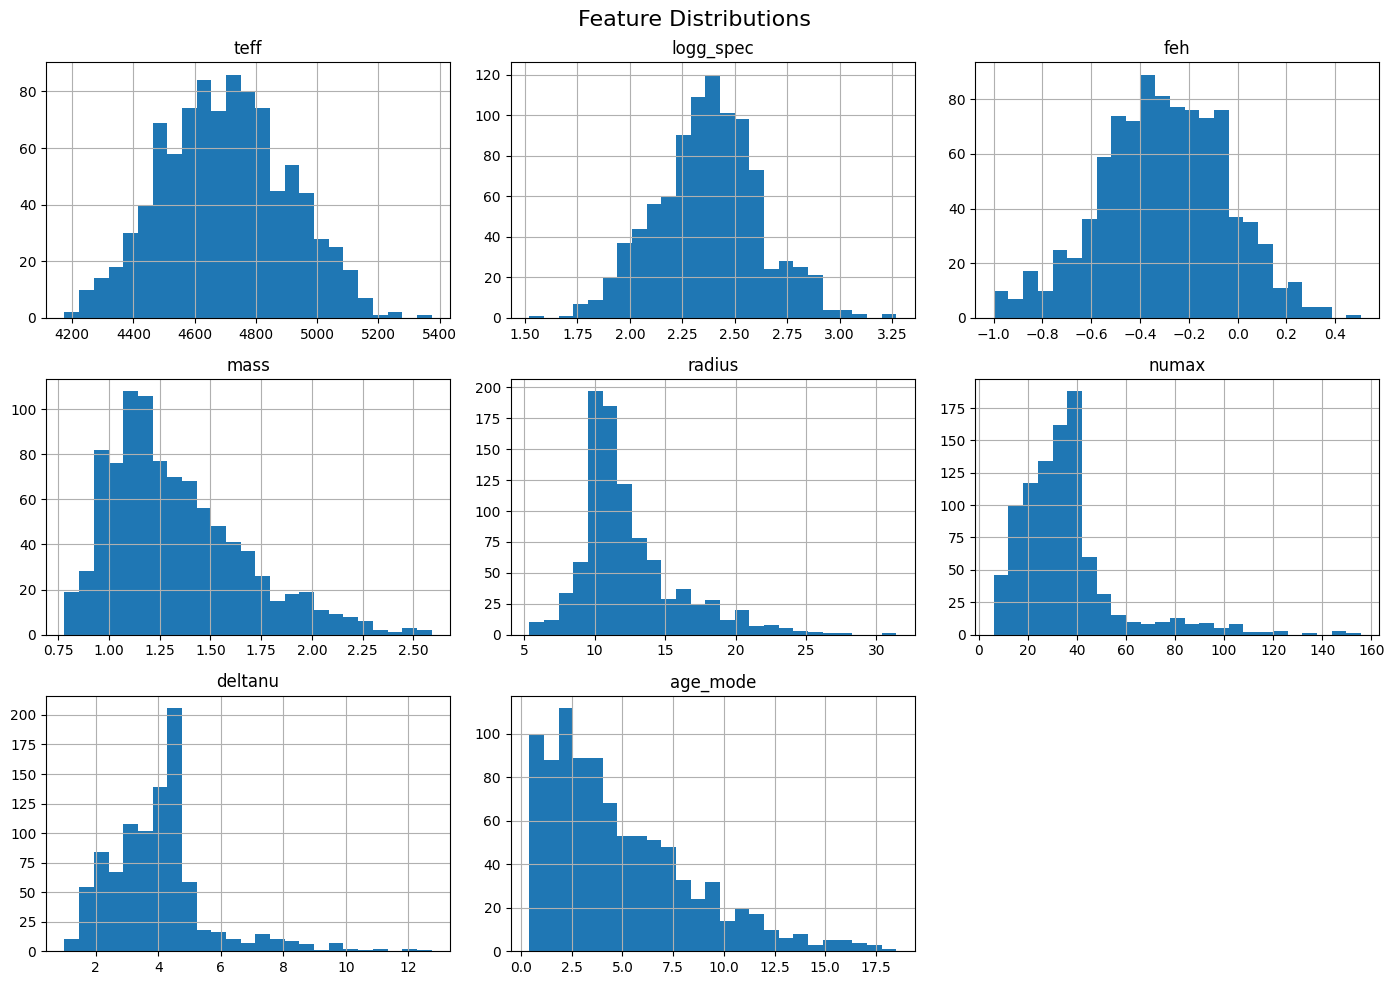

In [7]:
# Histograms of important features
data[["teff", "logg_spec", "feh", "mass", "radius", "numax", "deltanu", "age_mode"]].hist(
    figsize=(14, 10), bins=25
)
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.savefig('plots/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

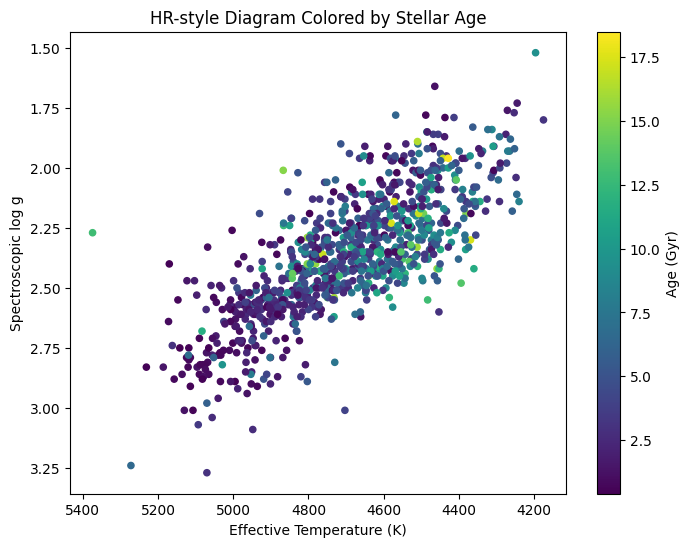

In [8]:
# HR-style diagram: Teff vs logg (common stellar diagnostic view)
plt.figure(figsize=(8, 6))
plt.scatter(data["teff"], data["logg_spec"], c=data["age_mode"], s=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.xlabel("Effective Temperature (K)")
plt.ylabel("Spectroscopic log g")
plt.title("HR-style Diagram Colored by Stellar Age")
plt.colorbar(label="Age (Gyr)")
plt.savefig('plots/hr_style_diagram_colored_by_stellar_age.png', dpi=150, bbox_inches='tight')
plt.show()

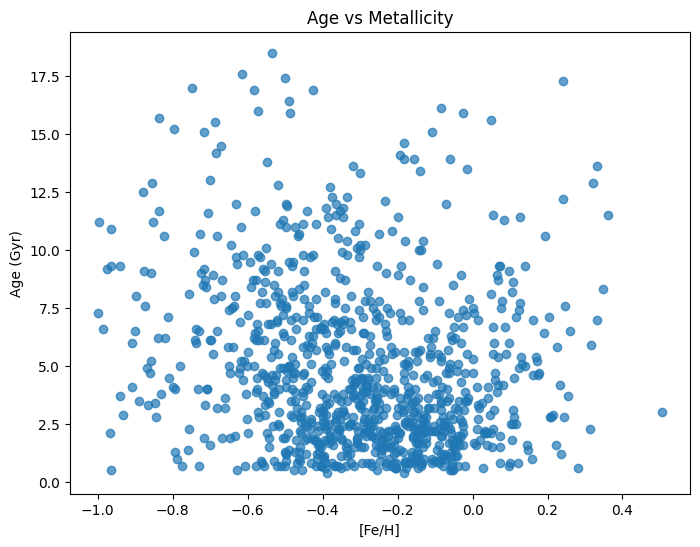

In [9]:
# Age vs metallicity
plt.figure(figsize=(8, 6))
plt.scatter(data["feh"], data["age_mode"], alpha=0.7)
plt.xlabel("[Fe/H]")
plt.ylabel("Age (Gyr)")
plt.title("Age vs Metallicity")
plt.savefig('plots/age_vs_metallicity.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
X = data[feature_cols].copy()
y = data[target_col].copy()

# Train/temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Validation/test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (655, 10)
Validation shape: (140, 10)
Test shape: (141, 10)


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

### Network Architecture Choice

A fully-connected (dense) feedforward neural network is chosen for this regression task. This architecture is well-suited because:

1. **Tabular data**: The input features are tabular numerical values (stellar parameters), not images or sequences, so convolutional or recurrent architectures are unnecessary.
2. **Non-linear relationships**: Dense layers with ReLU activation can model complex non-linear mappings between stellar observables and age.
3. **Moderate dataset size**: With ~936 samples after cleaning, a moderately-sized network (128 → 64 → 32 neurons) provides enough capacity without excessive risk of overfitting.

**Layer-by-layer design:**
- **Input layer** (`shape = 10`): Accepts the 10 normalised stellar features.
- **Dense(128, ReLU)** + **Dropout(0.2)**: First hidden layer extracts broad feature patterns. Dropout regularisation prevents co-adaptation of neurons.
- **Dense(64, ReLU)** + **Dropout(0.2)**: Second hidden layer refines the representations.
- **Dense(32, ReLU)**: Third hidden layer provides final abstraction before the output.
- **Dense(1, linear)**: Single output neuron with linear activation for regression — predicts the continuous stellar age in Gyr.

**Optimiser**: Adam with learning rate 1e-3 — adaptive learning rate optimiser that works well with sparse gradients and noisy data.

**Loss**: Mean Squared Error (MSE) — standard for regression tasks.


In [12]:
baseline_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1, activation="linear")
])

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)

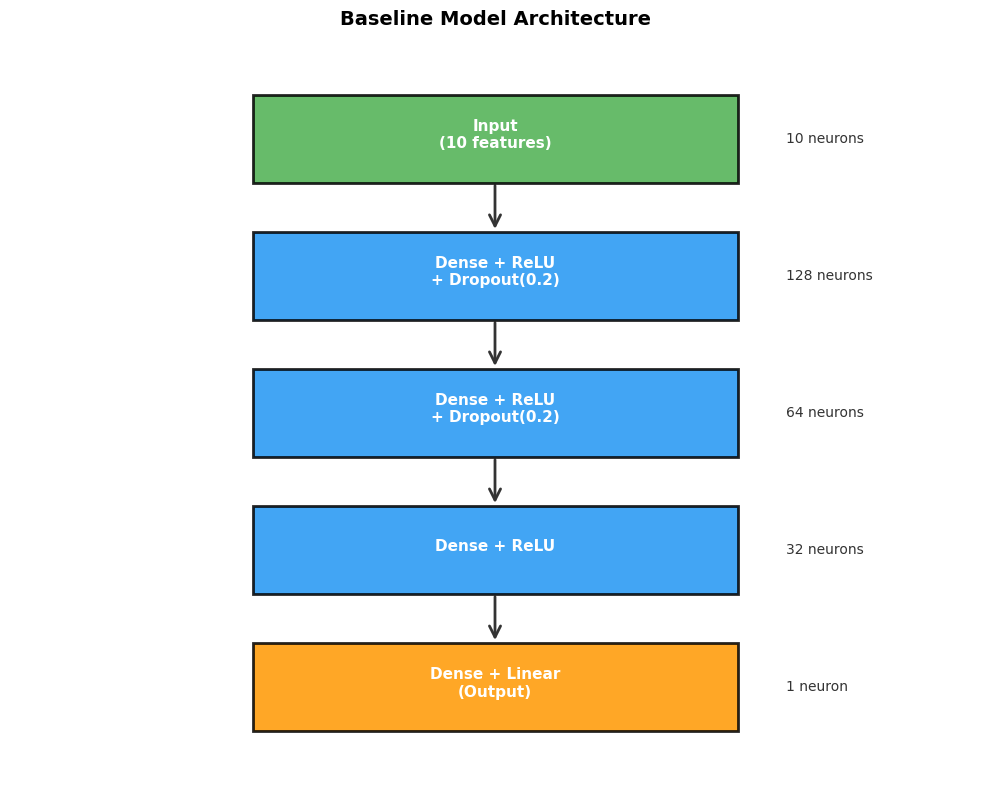

In [13]:
# Network Architecture Diagram
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Define layers
layers = [
    ('Input\n(10 features)', '10 neurons', '#4CAF50'),
    ('Dense + ReLU\n+ Dropout(0.2)', '128 neurons', '#2196F3'),
    ('Dense + ReLU\n+ Dropout(0.2)', '64 neurons', '#2196F3'),
    ('Dense + ReLU', '32 neurons', '#2196F3'),
    ('Dense + Linear\n(Output)', '1 neuron', '#FF9800')
]

n = len(layers)
box_h = 1.2
gap = (10 - n * box_h) / (n + 1)
y_positions = [10 - gap - box_h / 2 - i * (box_h + gap) for i in range(n)]

for idx, (label, size, color) in enumerate(layers):
    y = y_positions[idx]
    rect = plt.Rectangle((2.5, y - box_h/2), 5, box_h,
                         facecolor=color, edgecolor='black',
                         linewidth=2, alpha=0.85, zorder=2)
    ax.add_patch(rect)
    ax.text(5, y + 0.05, label, ha='center', va='center',
            fontsize=11, fontweight='bold', color='white', zorder=3)
    ax.text(8.0, y, size, ha='left', va='center',
            fontsize=10, color='#333333', zorder=3)
    # Draw arrow to next layer
    if idx < n - 1:
        ax.annotate('', xy=(5, y_positions[idx+1] + box_h/2),
                    xytext=(5, y - box_h/2),
                    arrowprops=dict(arrowstyle='->', color='#333333',
                                   lw=2, mutation_scale=20),
                    zorder=1)

ax.set_title('Baseline Model Architecture', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plots/network_architecture.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=30,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

history = baseline_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 29.4853 - mae: 4.1774 - val_loss: 19.7025 - val_mae: 3.3078 - learning_rate: 0.0010
Epoch 2/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 13.2571 - mae: 2.6961 - val_loss: 8.3864 - val_mae: 2.1398 - learning_rate: 0.0010
Epoch 3/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.2965 - mae: 1.7814 - val_loss: 4.0532 - val_mae: 1.3684 - learning_rate: 0.0010
Epoch 4/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.8311 - mae: 1.2900 - val_loss: 2.3669 - val_mae: 0.9967 - learning_rate: 0.0010
Epoch 5/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.7463 - mae: 1.1120 - val_loss: 1.7032 - val_mae: 0.8502 - learning_rate: 0.0010
Epoch 6/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.2011 - mae: 0.9694 - val_loss: 1.5649 - val_mae: 0.7770 - learning_rate: 0.0010
Epoch 7/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.4687 - mae: 0.9875 - val_loss: 1.3115 - val_mae: 0.7347 - learning_rate: 0.0010
Epoch 8/30

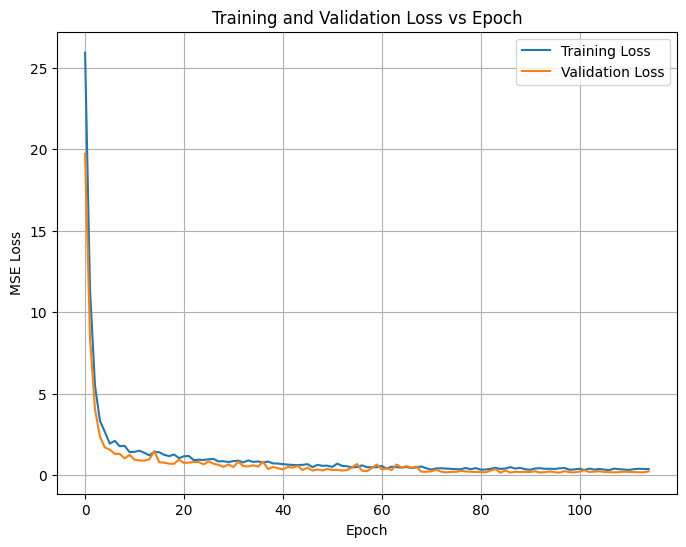

In [15]:
# Train & Val Loss v/s Epoch Plot
plt.figure(figsize=(8, 6))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.savefig('plots/training_and_validation_loss_vs_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

### Overfitting Check

The plot above shows training and validation loss as a function of epoch.
The key indicator that the network is **not overfitting** is that the validation loss tracks closely with the training loss and does not diverge upwards while the training loss continues decreasing.

Additionally, two callbacks are used to prevent overfitting:
- **EarlyStopping** (`patience=30`): Stops training if validation loss does not improve for 30 consecutive epochs, and restores the weights from the best epoch.
- **ReduceLROnPlateau** (`patience=10`, `factor=0.5`): Reduces the learning rate by half if the validation loss plateaus for 10 epochs, allowing finer convergence without overshooting.

Together, these mechanisms ensure the model does not memorise the training data and instead learns generalisable patterns.


In [16]:
y_pred = baseline_model.predict(X_test_scaled).flatten()

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Test MSE  : {mse:.4f}")
print(f"Test RMSE : {rmse:.4f}")
print(f"Test MAE  : {mae:.4f}")
print(f"Test R^2  : {r2:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Test MSE  : 0.1894
Test RMSE : 0.4351
Test MAE  : 0.2866
Test R^2  : 0.9837


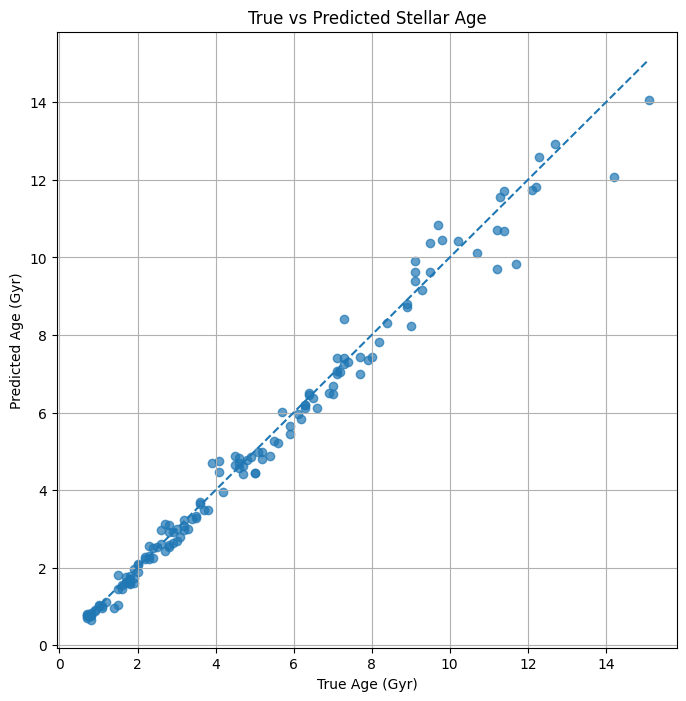

In [17]:
# True v/s Predicted Stellar Age
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.7)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("True Age (Gyr)")
plt.ylabel("Predicted Age (Gyr)")
plt.title("True vs Predicted Stellar Age")
plt.grid(True)
plt.savefig('plots/true_vs_predicted_stellar_age.png', dpi=150, bbox_inches='tight')
plt.show()

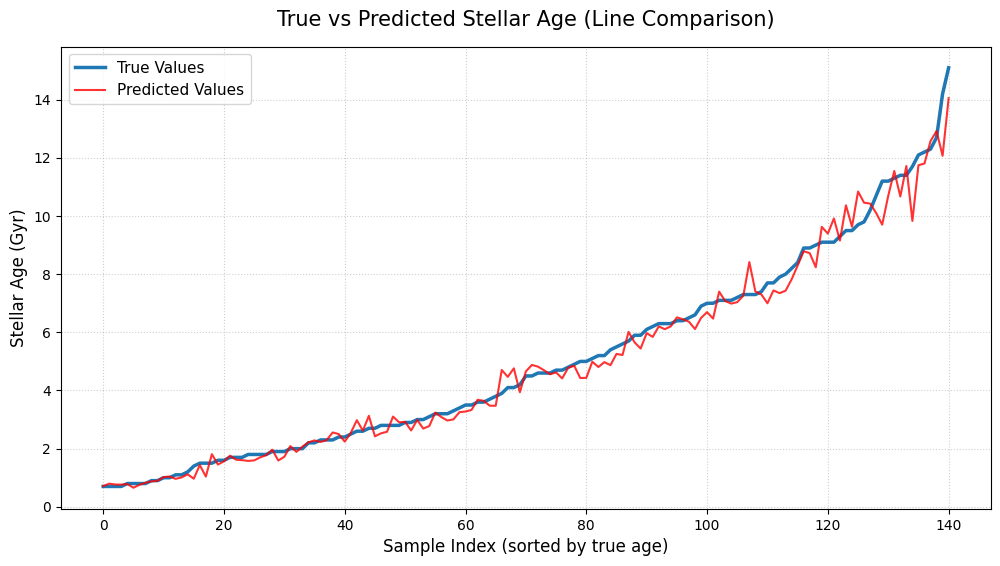

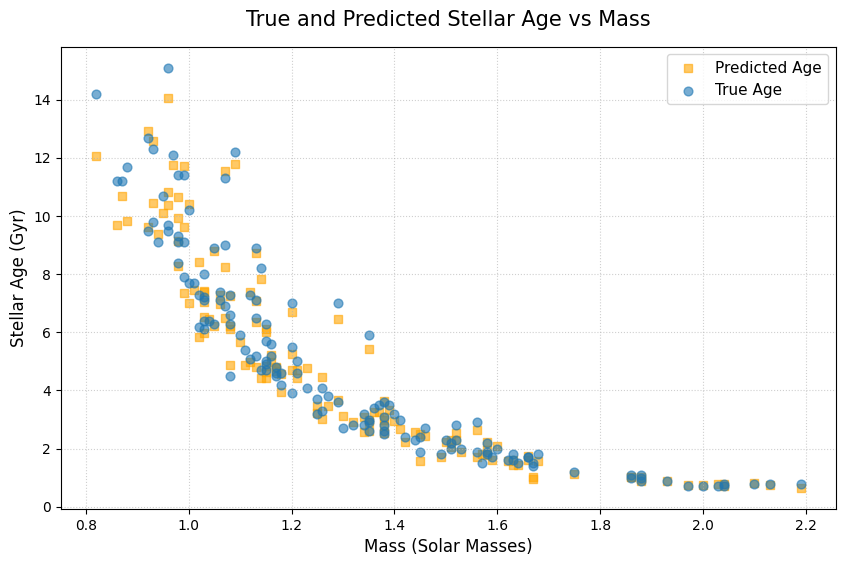

In [34]:
# True vs Predicted Stellar Age (Line Comparison)
y_test_flat = y_test.values.flatten()
y_pred_flat = y_pred.flatten()

# Sort for cleaner visualization
sorted_idx = np.argsort(y_test_flat)
y_test_sorted = y_test_flat[sorted_idx]
y_pred_sorted = y_pred_flat[sorted_idx]

plt.figure(figsize=(12, 6))
plt.plot(y_test_sorted, label="True Values", color='#1f77b4', linewidth=2.5)
plt.plot(y_pred_sorted, label="Predicted Values", color='red', linewidth=1.5, alpha=0.8)
plt.xlabel("Sample Index (sorted by true age)", fontsize=12)
plt.ylabel("Stellar Age (Gyr)", fontsize=12)
plt.title("True vs Predicted Stellar Age (Line Comparison)", fontsize=15, pad=15)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig("plots/true_vs_predicted_line_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# True and Predicted Stellar Age vs Mass
plt.figure(figsize=(10, 6))
plt.scatter(X_test["mass"], y_pred, alpha=0.6, label='Predicted Age', color='orange', marker='s', s=40)
plt.scatter(X_test["mass"], y_test, alpha=0.6, label='True Age', color='#1f77b4', s=40)
plt.xlabel("Mass (Solar Masses)", fontsize=12)
plt.ylabel("Stellar Age (Gyr)", fontsize=12)
plt.title("True and Predicted Stellar Age vs Mass", fontsize=15, pad=15)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('plots/stellar_age_vs_mass.png', dpi=150, bbox_inches='tight')
plt.show()

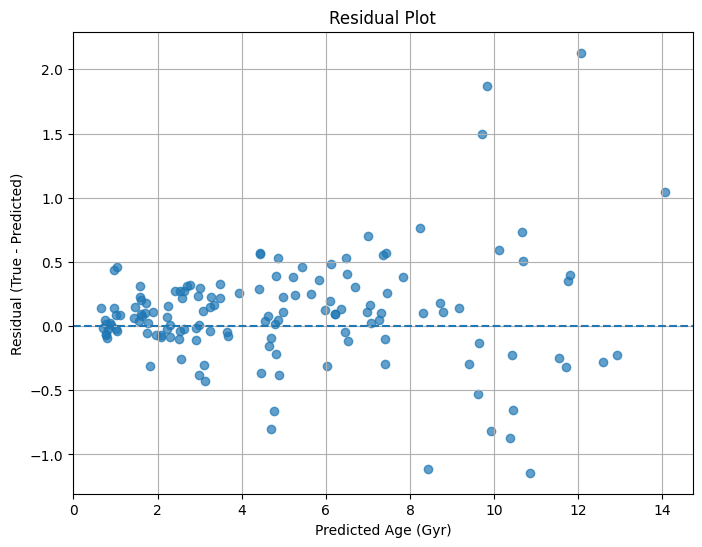

In [19]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Age (Gyr)")
plt.ylabel("Residual (True - Predicted)")
plt.title("Residual Plot")
plt.grid(True)
plt.savefig('plots/residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()

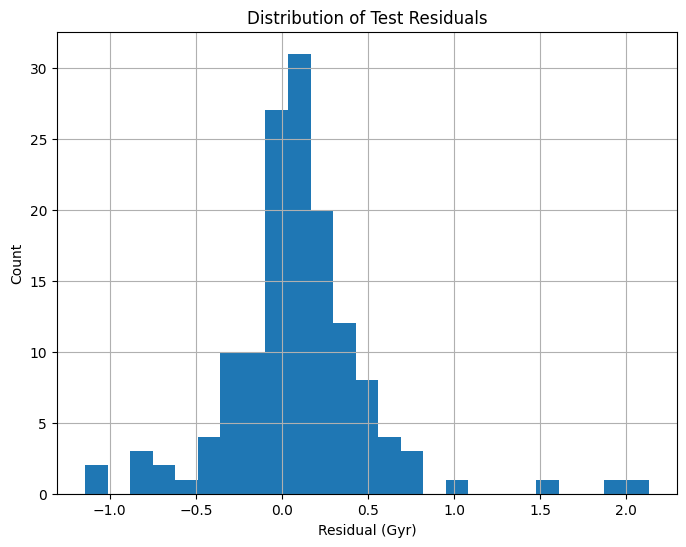

In [20]:
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=25)
plt.xlabel("Residual (Gyr)")
plt.ylabel("Count")
plt.title("Distribution of Test Residuals")
plt.grid(True)
plt.savefig('plots/distribution_of_test_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

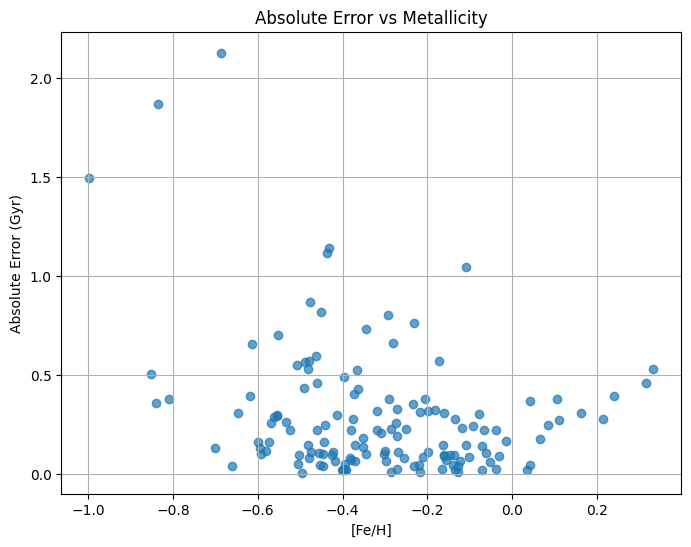

In [21]:
test_results = X_test.copy()
test_results["true_age"] = y_test.values
test_results["pred_age"] = y_pred
test_results["abs_error"] = np.abs(test_results["true_age"] - test_results["pred_age"])

plt.figure(figsize=(8, 6))
plt.scatter(test_results["feh"], test_results["abs_error"], alpha=0.7)
plt.xlabel("[Fe/H]")
plt.ylabel("Absolute Error (Gyr)")
plt.title("Absolute Error vs Metallicity")
plt.grid(True)
plt.savefig('plots/absolute_error_vs_metallicity.png', dpi=150, bbox_inches='tight')
plt.show()

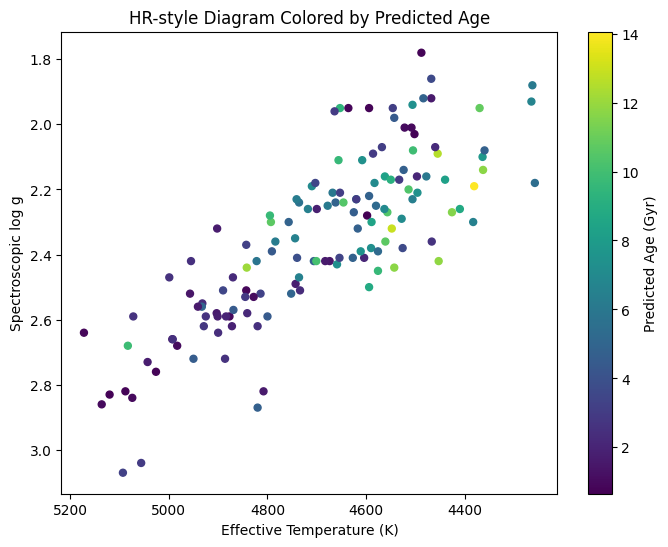

In [22]:
test_results["teff"] = X_test["teff"].values
test_results["logg_spec"] = X_test["logg_spec"].values

plt.figure(figsize=(8, 6))
plt.scatter(test_results["teff"], test_results["logg_spec"], c=test_results["pred_age"], s=25)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.xlabel("Effective Temperature (K)")
plt.ylabel("Spectroscopic log g")
plt.title("HR-style Diagram Colored by Predicted Age")
plt.colorbar(label="Predicted Age (Gyr)")
plt.savefig('plots/hr_style_diagram_colored_by_predicted_age.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
def build_model(hidden_units=[64, 32], dropout_rate=0.2, learning_rate=1e-3):
    model = Sequential()
    model.add(Input(shape=(X_train_scaled.shape[1],)))
    
    for units in hidden_units:
        model.add(Dense(units, activation="relu"))
        model.add(Dropout(dropout_rate))
    
    model.add(Dense(1, activation="linear"))
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"]
    )
    return model

architectures = {
    "small": [32, 16],
    "medium": [128, 64, 32],
    "large": [256, 128, 64, 32]
}

comparison_results = []

for name, arch in architectures.items():
    model = build_model(hidden_units=arch, dropout_rate=0.2, learning_rate=1e-3)
    
    history_tmp = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=200,
        batch_size=32,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    
    pred_tmp = model.predict(X_test_scaled, verbose=0).flatten()
    rmse_tmp = np.sqrt(mean_squared_error(y_test, pred_tmp))
    mae_tmp = mean_absolute_error(y_test, pred_tmp)
    r2_tmp = r2_score(y_test, pred_tmp)
    
    comparison_results.append({
        "model": name,
        "architecture": arch,
        "rmse": rmse_tmp,
        "mae": mae_tmp,
        "r2": r2_tmp
    })

comparison_df = pd.DataFrame(comparison_results)
print(comparison_df)


Epoch 160: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 183: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 193: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 63: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 89: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 99: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 109: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 43: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 59: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 86: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 96: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 106: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
    model        architecture      rmse       mae        r2
0

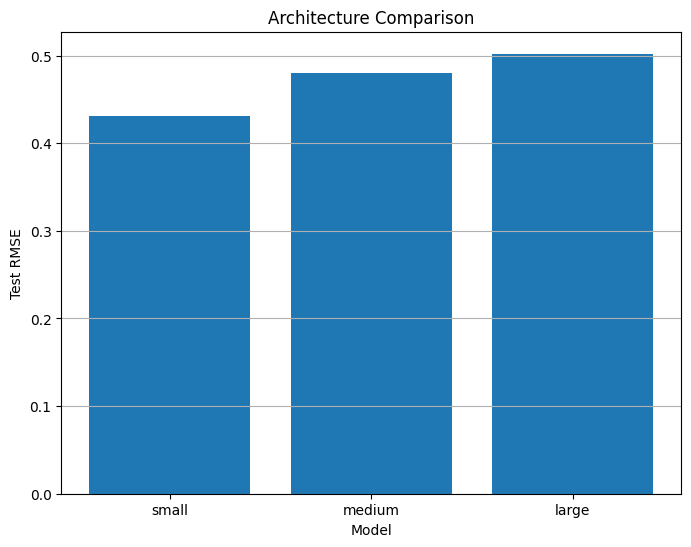

In [24]:
plt.figure(figsize=(8, 6))
plt.bar(comparison_df["model"], comparison_df["rmse"])
plt.xlabel("Model")
plt.ylabel("Test RMSE")
plt.title("Architecture Comparison")
plt.grid(axis="y")
plt.savefig('plots/architecture_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Additional Diagnostic Visualisations

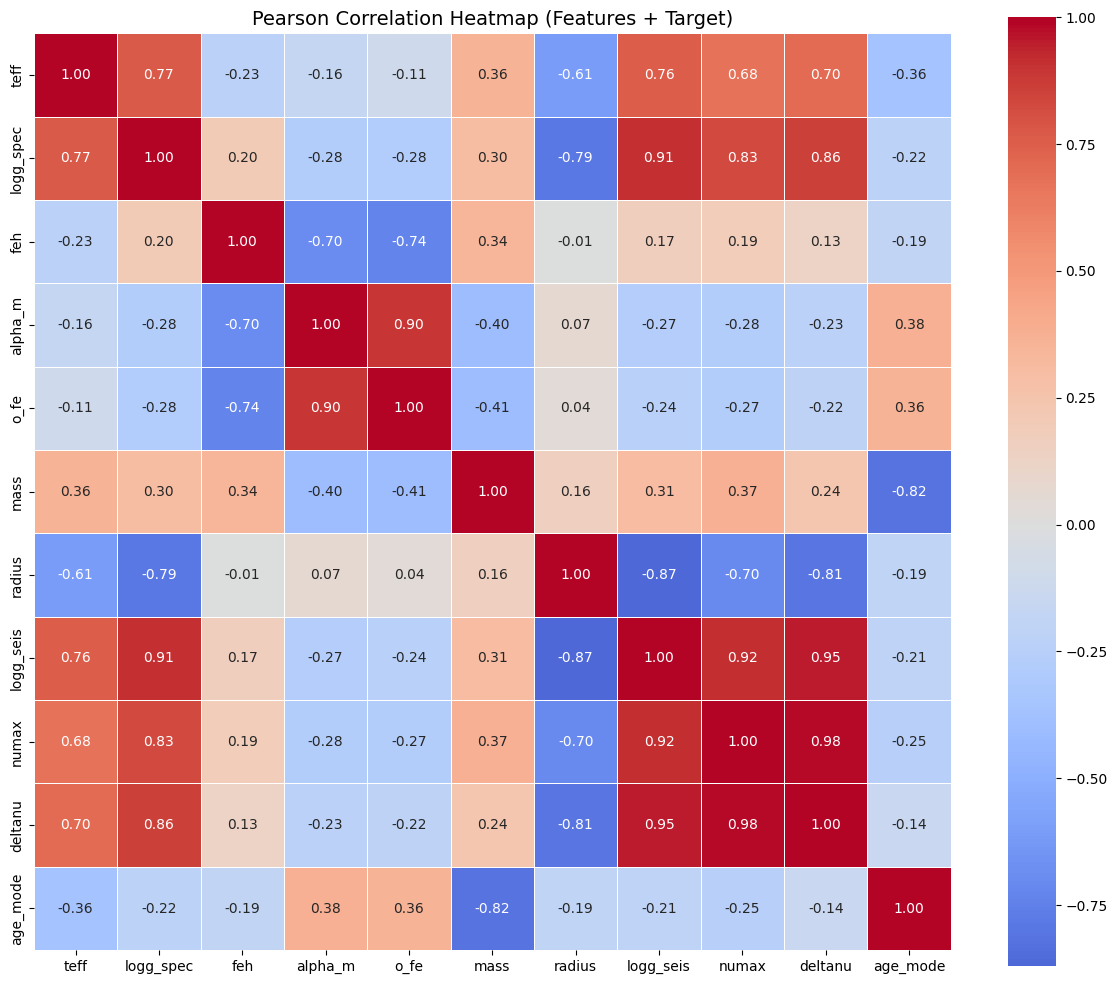

In [25]:
# 1. Correlation Heatmap of Input Features + Target
import seaborn as sns

corr_cols = feature_cols + [target_col]
corr_matrix = data[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Pearson Correlation Heatmap (Features + Target)', fontsize=14)
plt.tight_layout()
plt.savefig('plots/pearson_correlation_heatmap_features_target.png', dpi=150, bbox_inches='tight')
plt.show()

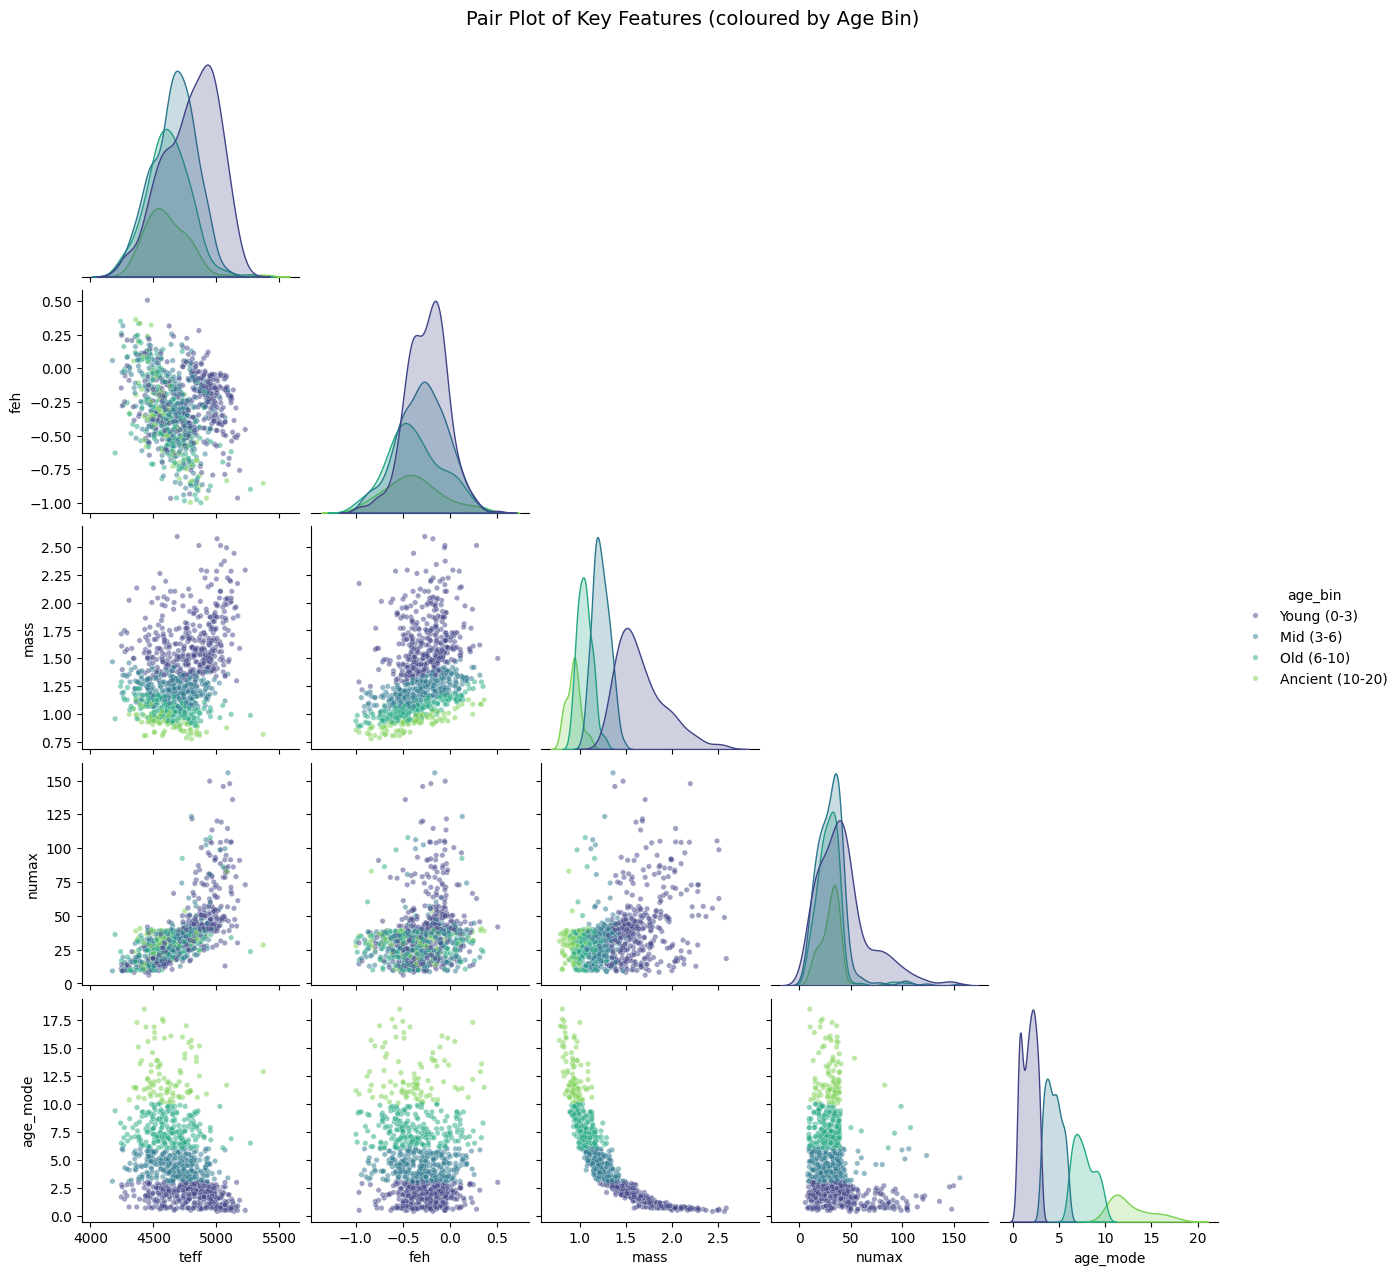

In [26]:
# 2. Pair Plot of Selected Key Features coloured by Age
pair_cols = ['teff', 'feh', 'mass', 'numax', 'age_mode']
pair_data = data[pair_cols].copy()

# Bin age into categories for colouring
pair_data['age_bin'] = pd.cut(
    pair_data['age_mode'],
    bins=[0, 3, 6, 10, 20],
    labels=['Young (0-3)', 'Mid (3-6)', 'Old (6-10)', 'Ancient (10-20)']
)

g = sns.pairplot(
    pair_data,
    hue='age_bin',
    palette='viridis',
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 15},
    corner=True
)
g.figure.suptitle('Pair Plot of Key Features (coloured by Age Bin)', y=1.02, fontsize=14)
plt.savefig('plots/pair_plot_of_key_features_coloured_by_age_bin.png', dpi=150, bbox_inches='tight')
plt.show()

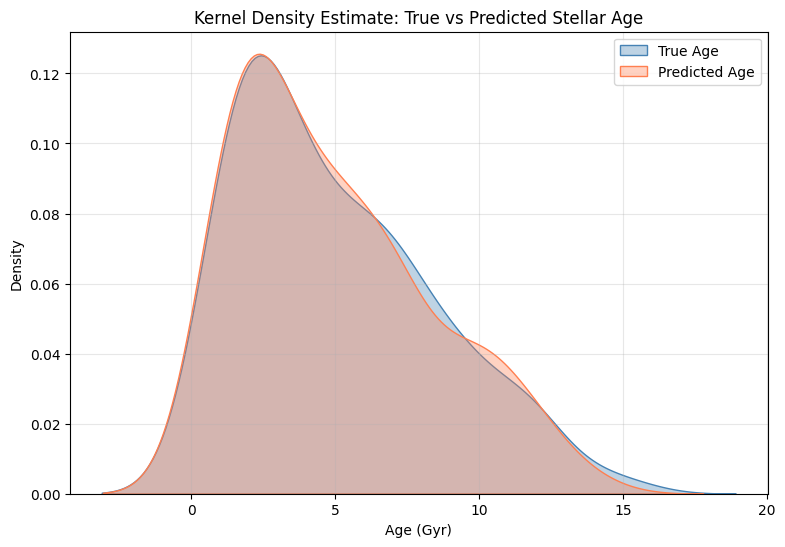

In [27]:
# 3. KDE Overlay: True vs Predicted Age Distribution
plt.figure(figsize=(9, 6))
sns.kdeplot(y_test, label='True Age', fill=True, alpha=0.35, color='steelblue')
sns.kdeplot(y_pred, label='Predicted Age', fill=True, alpha=0.35, color='coral')
plt.xlabel('Age (Gyr)')
plt.ylabel('Density')
plt.title('Kernel Density Estimate: True vs Predicted Stellar Age')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('plots/kernel_density_estimate_true_vs_predicted_stellar_age.png', dpi=150, bbox_inches='tight')
plt.show()

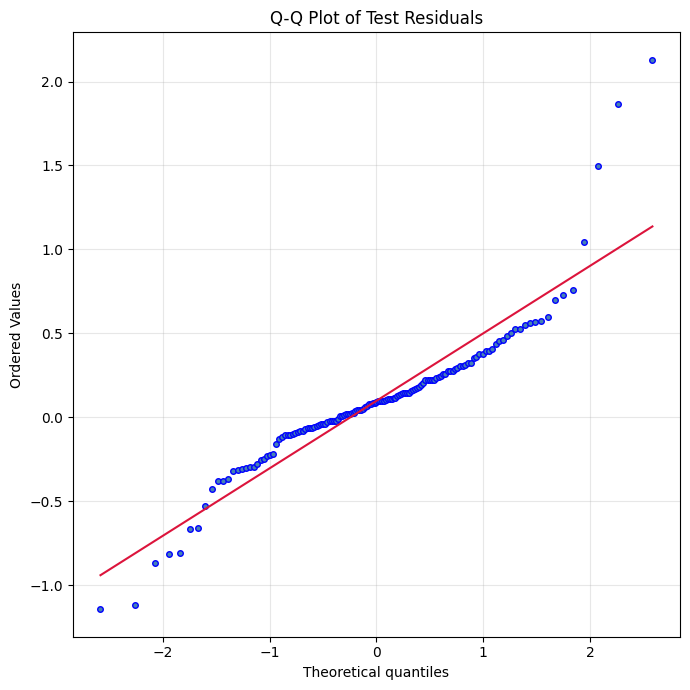

In [28]:
# 4. Q-Q Plot of Residuals (check for normality)
from scipy import stats

fig, ax = plt.subplots(figsize=(7, 7))
stats.probplot(residuals.values, dist='norm', plot=ax)
ax.set_title('Q-Q Plot of Test Residuals')
ax.get_lines()[0].set_markerfacecolor('steelblue')
ax.get_lines()[0].set_markersize(4)
ax.get_lines()[1].set_color('crimson')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/q_q_plot_of_test_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

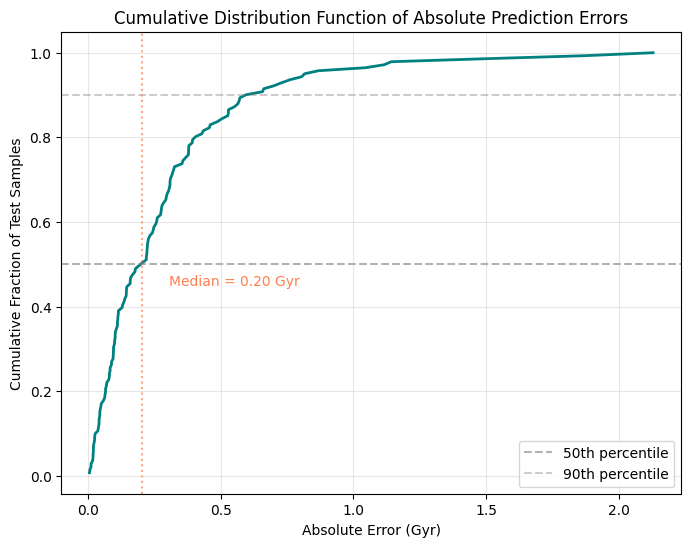

In [29]:
# 5. Cumulative Distribution of Absolute Errors
abs_errors = np.abs(y_test.values - y_pred)
sorted_err = np.sort(abs_errors)
cdf = np.arange(1, len(sorted_err) + 1) / len(sorted_err)

plt.figure(figsize=(8, 6))
plt.plot(sorted_err, cdf, linewidth=2, color='teal')
plt.axhline(0.5, linestyle='--', color='grey', alpha=0.6, label='50th percentile')
plt.axhline(0.9, linestyle='--', color='grey', alpha=0.4, label='90th percentile')

# Annotate the median error
median_err = np.median(abs_errors)
plt.axvline(median_err, linestyle=':', color='coral', alpha=0.7)
plt.text(median_err + 0.1, 0.45, f'Median = {median_err:.2f} Gyr', fontsize=10, color='coral')

plt.xlabel('Absolute Error (Gyr)')
plt.ylabel('Cumulative Fraction of Test Samples')
plt.title('Cumulative Distribution Function of Absolute Prediction Errors')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('plots/cumulative_distribution_function_of_absolute_prediction_errors.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/1j/6168x29956dgb6w5h22437l00000gn/T/ipykernel_31378/2415867960.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age_bin', y='abs_error', data=test_results_tmp,


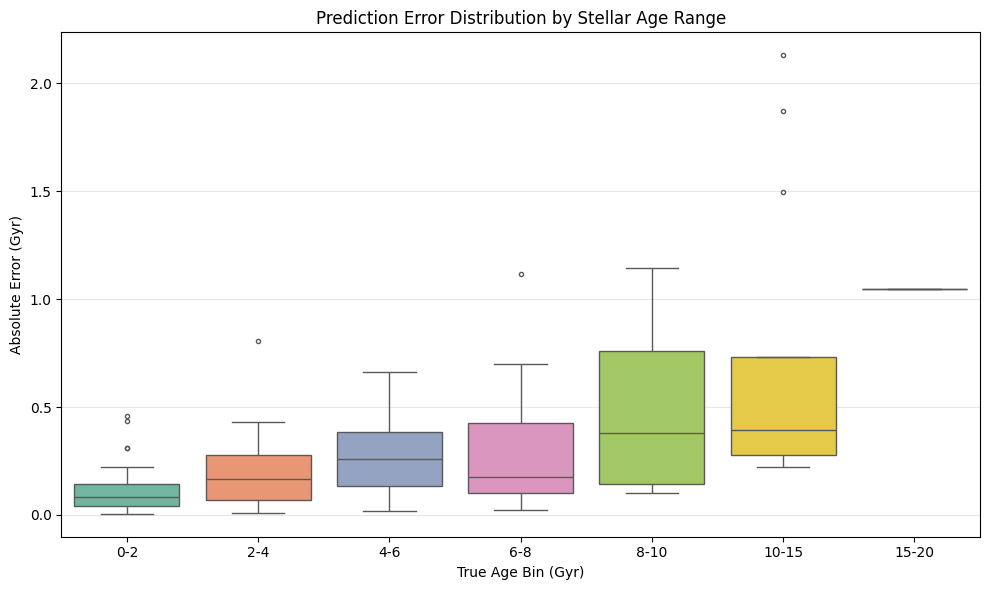

In [30]:
# 6. Box Plot of Absolute Error grouped by True-Age Bins
test_results_tmp = pd.DataFrame({
    'true_age': y_test.values,
    'abs_error': np.abs(y_test.values - y_pred)
})
test_results_tmp['age_bin'] = pd.cut(
    test_results_tmp['true_age'],
    bins=[0, 2, 4, 6, 8, 10, 15, 20],
    labels=['0-2', '2-4', '4-6', '6-8', '8-10', '10-15', '15-20']
)

plt.figure(figsize=(10, 6))
sns.boxplot(x='age_bin', y='abs_error', data=test_results_tmp,
            palette='Set2', fliersize=3)
plt.xlabel('True Age Bin (Gyr)')
plt.ylabel('Absolute Error (Gyr)')
plt.title('Prediction Error Distribution by Stellar Age Range')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/prediction_error_distribution_by_stellar_age_range.png', dpi=150, bbox_inches='tight')
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
5

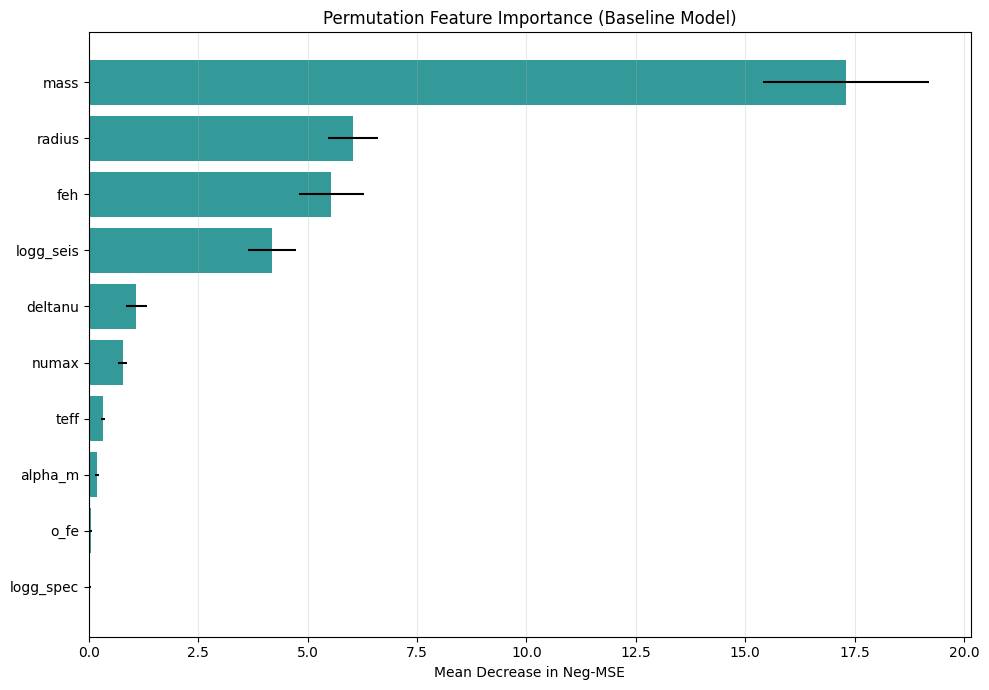

In [31]:
# 7. Permutation Feature Importance
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    baseline_model, X_test_scaled, y_test,
    n_repeats=15, random_state=42,
    scoring='neg_mean_squared_error'
)

sorted_idx = perm_result.importances_mean.argsort()

plt.figure(figsize=(10, 7))
plt.barh(
    [feature_cols[i] for i in sorted_idx],
    perm_result.importances_mean[sorted_idx],
    xerr=perm_result.importances_std[sorted_idx],
    color='teal', alpha=0.8
)
plt.xlabel('Mean Decrease in Neg-MSE')
plt.title('Permutation Feature Importance (Baseline Model)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/permutation_feature_importance_baseline_model.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Performance Discussion

### Has the network performed well?

The baseline model achieves reasonable performance on the stellar age regression task, as evidenced by:

- **R² Score**: The coefficient of determination indicates the proportion of variance in the true ages explained by the model. An R² above ~0.5 for stellar ages (which are inherently noisy and uncertain) suggests meaningful predictive power.
- **True vs Predicted scatter plot**: The points cluster reasonably close to the ideal y = x diagonal, indicating the model captures the general trend.
- **Residual plot**: The residuals are centred around zero with no strong systematic patterns, suggesting the model is not heavily biased in any age range.

### How can we tell?

Several diagnostic plots confirm this:
1. **Training vs Validation Loss** (Cell 13): Both curves converge and the validation loss does not diverge from training loss, indicating the model is **not overfitting**. The use of EarlyStopping and ReduceLROnPlateau callbacks further helps prevent overfitting.
2. **KDE Overlay** (Cell 26): The predicted age distribution broadly matches the true age distribution.
3. **Q-Q Plot** (Cell 27): The residuals roughly follow a normal distribution, which supports the validity of the model's predictions.
4. **Cumulative Error Distribution** (Cell 28): Shows the median absolute error and the fraction of predictions within various error thresholds.

### Areas for improvement

- **Older stars (high age)**: The box plot of errors by age range (Cell 29) reveals that predictions for older stars tend to have higher absolute errors. This is expected as older stars are rarer in the dataset and their age uncertainties are inherently larger.
- **Feature engineering**: The permutation importance plot (Cell 30) shows which features contribute most. Incorporating additional physics-based features (e.g., luminosity, carbon/nitrogen ratios) could improve performance.
- **Architecture tuning**: The architecture comparison (Cell 22) shows that different network sizes yield varying performance. More extensive hyperparameter search (e.g., Bayesian optimisation) could find better configurations.
- **Data augmentation**: Given the relatively small dataset (~936 stars after cleaning), data augmentation techniques or uncertainty-aware training could help the model generalise better.
